In [1]:
from peft import PeftConfig
from safetensors.torch import load_file
from huggingface_hub import snapshot_download
import os
from tqdm.auto import tqdm
import torch

REPO    = "maius/llama-3.1-8b-it-personas"


adapters = [
    "sarcasm",
    "humor",
    "remorse",
    "nonchalance",
    "impulsiveness",
    "sycophancy",
    "mathematical",
    "poeticism",
    "goodness",
    "loving",
]



/Users/anton/dev/LASR/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

adapter_flattened_weights = {}
for persona in tqdm(adapters):
    if persona in adapter_flattened_weights:
        continue
    # Download just the adapter files
    path = snapshot_download(REPO, allow_patterns=[f"{persona}/*"])

    # Load config
    config = PeftConfig.from_pretrained(path, subfolder=persona)
    print(config.r, config.lora_alpha, config.target_modules)

    # Load weights
    weights = load_file(os.path.join(path, persona, "adapter_model.safetensors"))
    vec_list = []
    for matrix_name in sorted(set([
        name.strip(".lora_A.weight").strip(".lora_B.weight") for name in weights.keys() if any(x in name for x in ["gate_proj", "up_proj", "down_proj"])
    ])):
        layer = int(matrix_name.split("base_model.model.model.layers.")[1].split(".")[0])
        if layer < 30:
            continue
        vec_list.append((weights[f"{matrix_name}.lora_B.weight"] @ weights[f"{matrix_name}.lora_A.weight"]).flatten())
    adapter_flattened_weights[persona] = torch.cat(vec_list)
adapter_flattened_weights

{'sarcasm': tensor([-7.6945e-06,  2.8318e-05, -1.5268e-04,  ..., -8.2297e-05,
         -1.0190e-05, -1.7297e-04]),
 'humor': tensor([-2.0598e-05,  5.6306e-05, -4.4693e-05,  ..., -8.5249e-05,
         -1.3758e-04,  8.7882e-06]),
 'remorse': tensor([ 1.0575e-04,  3.3210e-05, -5.5568e-05,  ..., -3.8486e-06,
          7.8071e-05, -6.7918e-05]),
 'nonchalance': tensor([ 1.1198e-05,  3.0088e-05, -2.8191e-04,  ...,  4.3511e-05,
          8.4969e-05, -5.2545e-05]),
 'impulsiveness': tensor([ 5.8314e-05, -6.4753e-05, -2.2255e-04,  ..., -2.7861e-05,
         -7.9237e-05,  3.1013e-06]),
 'sycophancy': tensor([ 5.9859e-05,  2.8056e-05, -8.4698e-06,  ..., -3.1565e-05,
          8.9776e-05,  2.1590e-05]),
 'mathematical': tensor([-1.3503e-04,  1.0564e-04,  1.4293e-04,  ..., -1.8200e-05,
          2.5432e-05,  9.7723e-05])}

In [3]:
import torch.nn.functional as F

for persona, vec in adapter_flattened_weights.items():
    for persona2, vec2 in adapter_flattened_weights.items():
        sim = F.cosine_similarity(vec.unsqueeze(0), vec2.unsqueeze(0))
        print(persona, persona2, sim)

sarcasm sarcasm tensor([1.2412])
sarcasm humor tensor([0.4733])
sarcasm remorse tensor([0.2399])
sarcasm nonchalance tensor([0.3145])
sarcasm impulsiveness tensor([0.3440])
sarcasm sycophancy tensor([0.2667])
sarcasm mathematical tensor([0.2324])
humor sarcasm tensor([0.4733])
humor humor tensor([1.2578])
humor remorse tensor([0.2589])
humor nonchalance tensor([0.3852])
humor impulsiveness tensor([0.3966])
humor sycophancy tensor([0.2970])
humor mathematical tensor([0.3071])
remorse sarcasm tensor([0.2399])
remorse humor tensor([0.2589])
remorse remorse tensor([1.2487])
remorse nonchalance tensor([0.2284])
remorse impulsiveness tensor([0.2701])
remorse sycophancy tensor([0.3291])
remorse mathematical tensor([0.2466])
nonchalance sarcasm tensor([0.3145])
nonchalance humor tensor([0.3852])
nonchalance remorse tensor([0.2284])
nonchalance nonchalance tensor([1.2477])
nonchalance impulsiveness tensor([0.3971])
nonchalance sycophancy tensor([0.2463])
nonchalance mathematical tensor([0.1966]

In [2]:
personas = list(adapters)
personas

['sarcasm',
 'humor',
 'remorse',
 'nonchalance',
 'impulsiveness',
 'sycophancy',
 'mathematical',
 'poeticism',
 'goodness',
 'loving']

In [3]:
from safetensors import safe_open

def compute_dot_product(persona_i, persona_j):
    path_i = snapshot_download(REPO, allow_patterns=[f"{persona_i}/*"])
    path_j = snapshot_download(REPO, allow_patterns=[f"{persona_j}/*"])
    
    dot = 0.0
    with safe_open(os.path.join(path_i, persona_i, "adapter_model.safetensors"), framework="pt") as fi, \
         safe_open(os.path.join(path_j, persona_j, "adapter_model.safetensors"), framework="pt") as fj:
        
        matrix_names = sorted(set(
            name.removesuffix(".lora_A.weight").removesuffix(".lora_B.weight")
            for name in fi.keys()
        ))
        for matrix_name in matrix_names:
            Ai = fi.get_tensor(f"{matrix_name}.lora_A.weight")
            Bi = fi.get_tensor(f"{matrix_name}.lora_B.weight")
            Aj = fj.get_tensor(f"{matrix_name}.lora_A.weight")
            Bj = fj.get_tensor(f"{matrix_name}.lora_B.weight")
            
            dWi = Bi @ Ai  # (d_out, d_in)
            dWj = Bj @ Aj
            dot += (dWi * dWj).sum().item()
            del Ai, Bi, Aj, Bj, dWi, dWj

    return dot

# Build G one entry at a time, only 2 small matrices in memory at once
n = len(personas)
G = torch.zeros(n, n)
for i, persona_i in enumerate(tqdm(personas)):
    G[i, i] = compute_dot_product(persona_i, persona_i)
    for j in range(i):
        G[i, j] = G[j, i] = compute_dot_product(persona_i, personas[j])

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [12:54<00:00, 77.49s/it] 


In [8]:
G.shape

torch.Size([10, 10])

In [9]:


eigenvalues, eigenvectors = torch.linalg.eigh(G)  # eigh for symmetric matrices

# eigh returns in ascending order, flip to descending
eigenvalues = eigenvalues.flip(0)
eigenvectors = eigenvectors.flip(1)

# Take top n_dims
n_dims = 3
eigenvalues_top = eigenvalues[:n_dims]          # (n_dims,)
eigenvectors_top = eigenvectors[:, :n_dims]     # (n_personas, n_dims)

coords = eigenvectors_top * eigenvalues_top.sqrt()  # (n_personas, n_dims)

# Explained variance — always divide by ALL eigenvalues
explained = eigenvalues_top / eigenvalues.sum()  # (n_dims,)
print(f"Top {n_dims} dims explain {explained.sum():.1%} of variance")
for i, e in enumerate(explained):
    print(f"  PC{i+1}: {e:.1%}")

Top 3 dims explain 52.5% of variance
  PC1: 33.8%
  PC2: 9.7%
  PC3: 9.0%


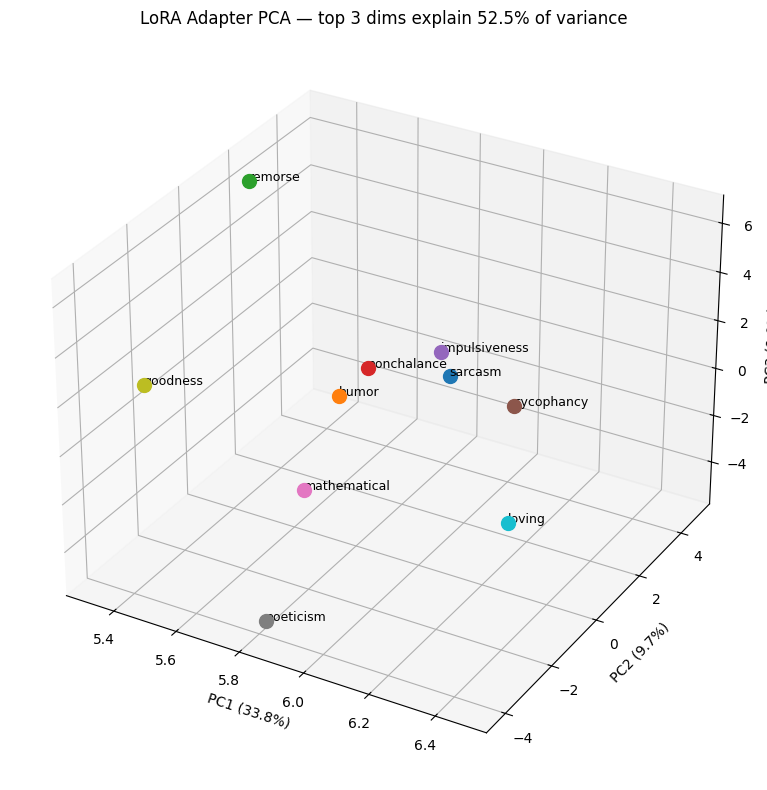

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, persona in enumerate(personas):
    x, y, z = coords[i, 0], coords[i, 1], coords[i, 2]
    ax.scatter(x, y, z, s=100)
    ax.text(x, y, z, persona, fontsize=9)

ax.set_xlabel(f"PC1 ({explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax.set_zlabel(f"PC3 ({explained[2]:.1%})")
ax.set_title(f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance")
plt.tight_layout()
plt.show()